# Section 3 Part 1: Complex Model Fit



In [13]:
from pathlib import Path
import json

import numpy as np
import pandas as pd
from IPython.display import display
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator, NullLocator

try:
    import scienceplots
except ModuleNotFoundError:
    scienceplots = None
else:
    plt.style.use("science")


def find_section_root(start: Path) -> Path:
    start = start.resolve()
    for path in [start, *start.parents]:
        if (path / "section_3" / "src" / "inference.py").exists():
            return path / "section_3"
        if path.name == "section_3" and (path / "src" / "inference.py").exists():
            return path
    raise FileNotFoundError("Could not locate section_3 root from current working directory.")


section_root = find_section_root(Path.cwd())
latest_path = section_root / "results" / "part_1_complex_latest.txt"
run_rel = latest_path.read_text().strip()
run_dir = section_root / "results" / run_rel
figure_dir = section_root / "figures" / "part_1_complex"
figure_dir.mkdir(parents=True, exist_ok=True)

run_config = json.loads((run_dir / "run_config.json").read_text())

config_df = (
    pd.Series(run_config)
    .rename_axis("setting")
    .reset_index(name="value")
)

display(config_df)


,setting,value
0,T,1.0
1,beta_prior_sd,1.0
2,cells,"[10, 20, 30, 40, 50, 100, 200, 400, 500, 1000]"
3,chains,6
4,correlation_threshold,0.01
5,gt_beta_x,0.8
6,gt_beta_y,-0.8
7,gt_mean_lambda,4.0
8,gt_p0,0.25
9,gt_sigma_eta,0.75


In [ ]:
PARAMETERS = [
    "mu_lambda",
    "sigma_lambda",
    "mu_p0",
    "sigma_eta",
    "beta_x",
    "beta_y",
]

PARAM_LABELS = {
    "mu_lambda": r"$\mu_\lambda$",
    "sigma_lambda": r"$\sigma_\lambda$",
    "p_zero": r"$\phi_0$",
    "mu_p0": r"$\mu_{p_0}$",
    "sigma_eta": r"$\sigma_\eta$",
    "beta_x": r"$\beta_x$",
    "beta_y": r"$\beta_y$",
}

LABEL_SIZE = 30
TICK_SIZE = 24
LEGEND_SIZE = 28
TICK_NBINS = 4
GROUND_TRUTH_COLOR = "#D55E00"
GROUND_TRUTH_LINESTYLE = "--"
GROUND_TRUTH_LINEWIDTH = 1.2
POSTERIOR_COLOR = "#2F80ED"


def param_display_label(param: str) -> str:
    return PARAM_LABELS.get(param, param)


def sample_size_ticks(sample_sizes, xscale: str) -> list[int]:
    sizes = sorted(int(x) for x in sample_sizes)
    lo, hi = sizes[0], sizes[-1]

    if xscale == "log":
        ticks = []
        start_decade = int(np.floor(np.log10(lo)))
        end_decade = int(np.ceil(np.log10(hi)))
        for decade in range(start_decade, end_decade + 1):
            for multiplier in (1, 2, 5):
                tick = int(multiplier * (10 ** decade))
                if lo <= tick <= hi:
                    ticks.append(tick)
    else:
        locator = MaxNLocator(nbins=6, integer=True)
        ticks = [int(t) for t in locator.tick_values(lo, hi) if lo <= t <= hi]

    ticks.extend([lo, hi])
    return sorted(set(ticks))


def hdi_columns(summary: pd.DataFrame) -> tuple[str | None, str | None]:
    lower = next((col for col in summary.columns if col.startswith("hdi_") and col.endswith("2.5%")), None)
    upper = next((col for col in summary.columns if col.startswith("hdi_") and col.endswith("97.5%")), None)
    if lower is None or upper is None:
        hdi_cols = [col for col in summary.columns if col.startswith("hdi_")]
        if len(hdi_cols) >= 2:
            lower, upper = hdi_cols[0], hdi_cols[-1]
    return lower, upper


rows = []
logml_rows = []

for n_dir in sorted([p for p in run_dir.iterdir() if p.is_dir() and p.name.isdigit()], key=lambda p: int(p.name)):
    summary_path = n_dir / "posterior_summary_complex_smc.csv"
    true_path = n_dir / "true_parameters.csv"
    logml_path = n_dir / "log_marginal_likelihood_complex_smc.csv"
    if not summary_path.exists():
        continue

    summary = pd.read_csv(summary_path, index_col=0)
    true_params = pd.read_csv(true_path).iloc[0].to_dict()
    hdi_low, hdi_high = hdi_columns(summary)
    n_cell = int(n_dir.name)

    for param in PARAMETERS:
        if param not in summary.index:
            continue
        rows.append(
            {
                "n_cell": n_cell,
                "parameter": param,
                "mean": float(summary.loc[param, "mean"]),
                "hdi_low": float(summary.loc[param, hdi_low]) if hdi_low else np.nan,
                "hdi_high": float(summary.loc[param, hdi_high]) if hdi_high else np.nan,
                "true": float(true_params[param]),
            }
        )

    if logml_path.exists():
        logml = pd.read_csv(logml_path).iloc[0]
        logml_rows.append({"n_cell": n_cell, "logml": float(logml["logml"])})

posterior_long = pd.DataFrame(rows)
logml_df = pd.DataFrame(logml_rows).sort_values("n_cell")
sample_sizes = sorted(posterior_long["n_cell"].unique())


(   n_cell     parameter   mean  hdi_low  hdi_high  true
 0      10     mu_lambda  3.455    1.691     5.483  4.00
 1      10  sigma_lambda  3.112    1.530     5.015  2.00
 2      10         mu_p0  0.372    0.149     0.606  0.25
 3      10     sigma_eta  0.521    0.002     1.309  0.75
 4      10        beta_x  1.200    0.347     2.082  0.80,
    n_cell        logml
 0      10   -57.389026
 1      20  -113.057841
 2      30  -152.279133
 3      40  -173.275926
 4      50  -203.837702
 5     100  -467.813659
 6     200  -965.584109
 7     400 -1925.352140
 8     500 -2438.520517
 9    1000 -4835.990478)

<>:32: SyntaxWarning: invalid escape sequence '\%'
<>:32: SyntaxWarning: invalid escape sequence '\%'
/var/folders/rr/16wv6ts1785fz6_2qhr5bc2m0000gn/T/ipykernel_56257/1094555380.py:32: SyntaxWarning: invalid escape sequence '\%'
  label="95 \% HDI",


PosixPath('/Users/marsian/PhD_LifeSciRes/Orca/section_3/figures/part_1_complex/complex_model_parameter_recovery_log.svg')

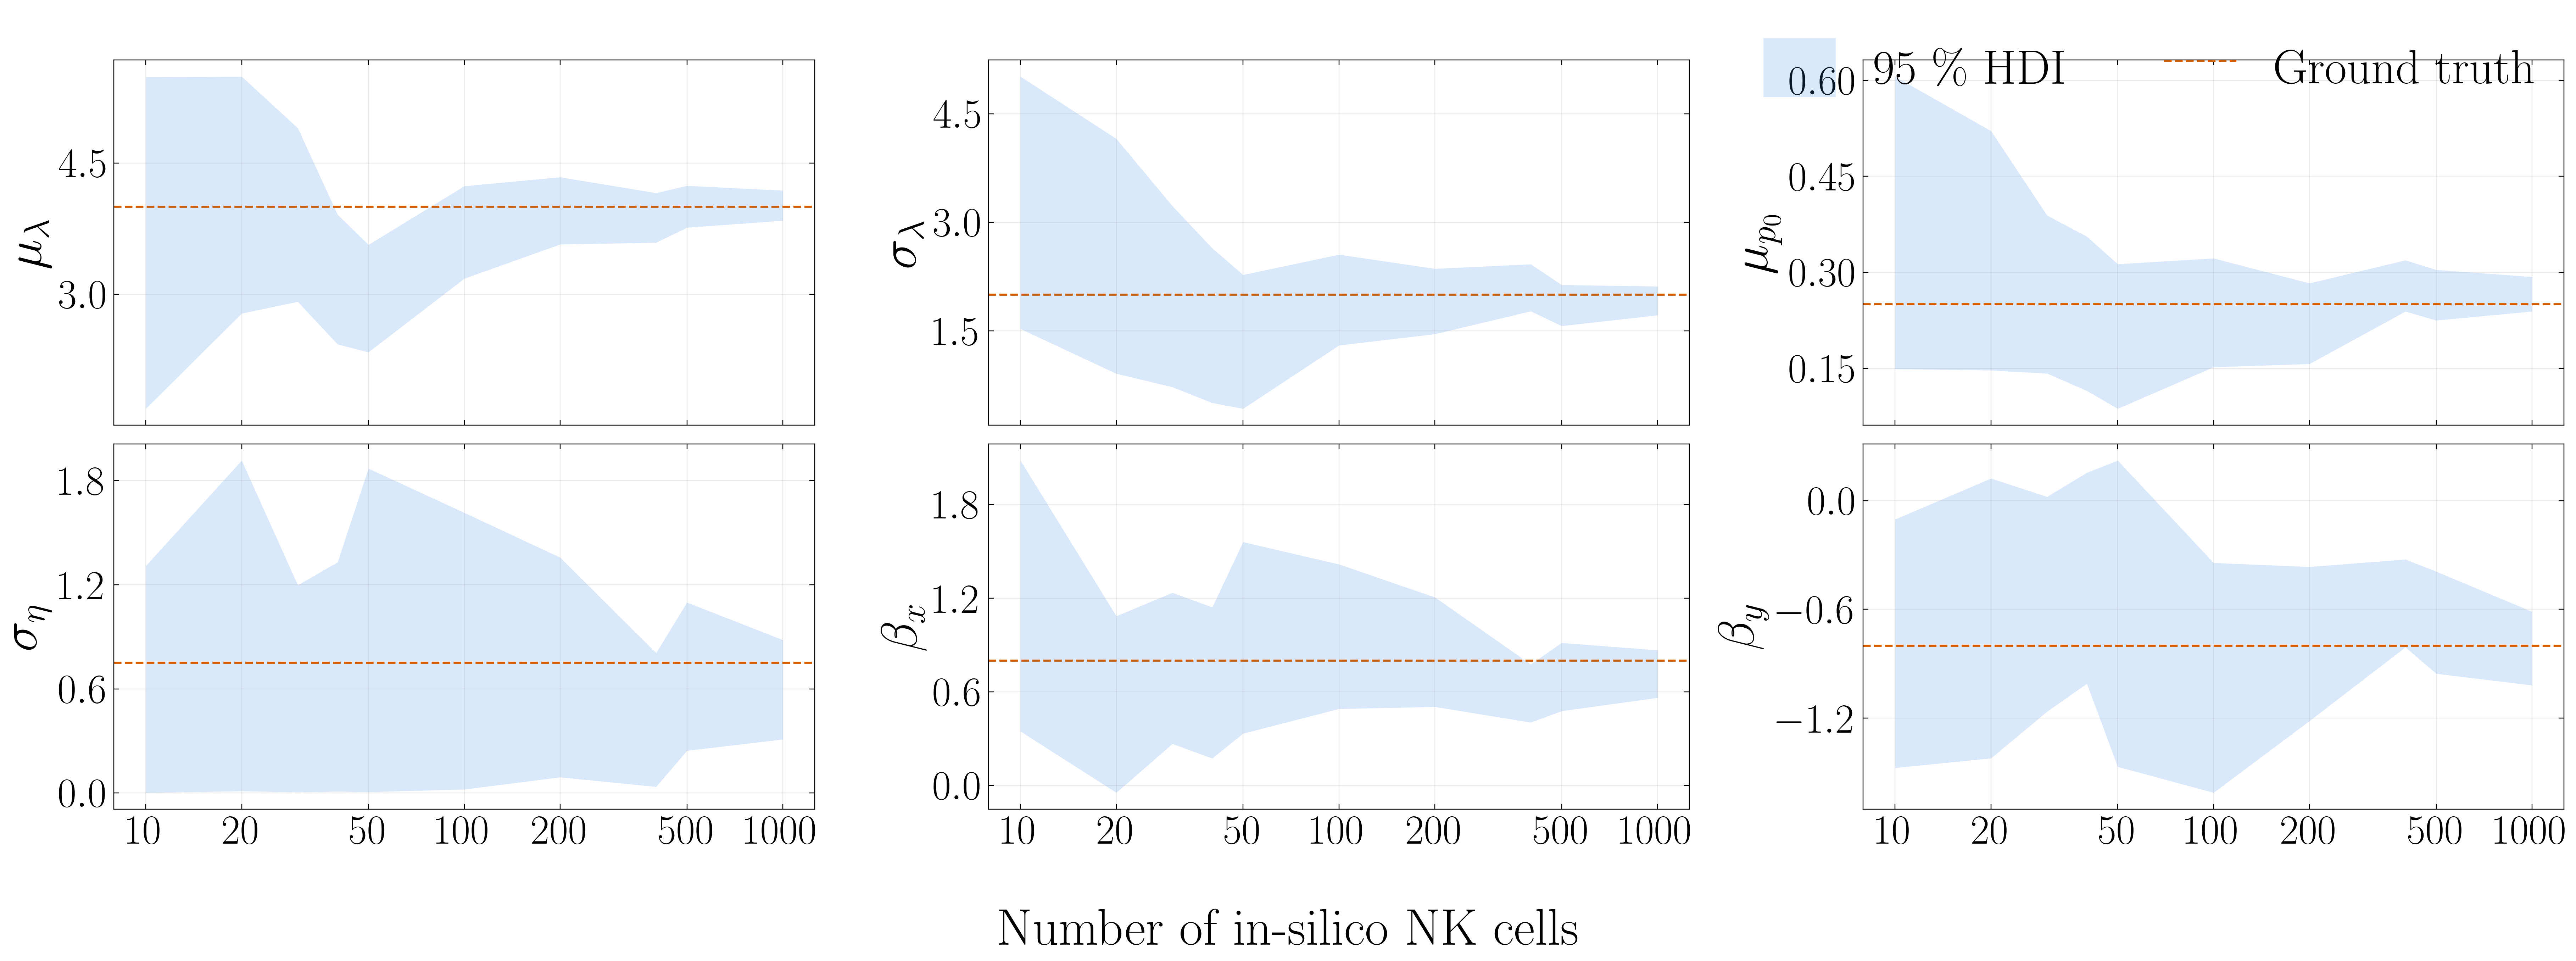

In [ ]:
xscale = "log"

fig, axes = plt.subplots(
    2,
    3,
    figsize=(21, 8),
    dpi=350,
    sharex=True,
)
axes = axes.ravel()

for ax, param in zip(axes, PARAMETERS):
    ax.set_facecolor("none")
    sub = posterior_long[posterior_long["parameter"] == param].sort_values("n_cell")
    if sub.empty:
        ax.axis("off")
        continue

    x = sub["n_cell"].to_numpy(dtype=float)
    mean = sub["mean"].to_numpy(dtype=float)
    lo = sub["hdi_low"].to_numpy(dtype=float)
    hi = sub["hdi_high"].to_numpy(dtype=float)
    true_value = float(sub["true"].iloc[0])

    ax.fill_between(
        x,
        lo,
        hi,
        color=POSTERIOR_COLOR,
        alpha=0.18,
        linewidth=0,
        label="95 \% HDI",
    )
    # ax.plot(
    #     x,
    #     mean,
    #     marker="o",
    #     markersize=3.5,
    #     linewidth=1.4,
    #     color=POSTERIOR_COLOR,
    #     label="Posterior mean",
    # )
    ax.axhline(
        true_value,
        color=GROUND_TRUTH_COLOR,
        linestyle=GROUND_TRUTH_LINESTYLE,
        linewidth=GROUND_TRUTH_LINEWIDTH,
        label="Ground truth",
    )

    ax.set_ylabel(param_display_label(param), fontsize=LABEL_SIZE)
    ax.grid(alpha=0.25)
    ax.set_xscale(xscale)
    ax.tick_params(axis="both", which="major", labelsize=TICK_SIZE)
    ax.yaxis.set_major_locator(MaxNLocator(nbins=TICK_NBINS))
    ax.xaxis.set_minor_locator(NullLocator())
    ax.yaxis.set_minor_locator(NullLocator())
    ax.minorticks_off()

x_ticks = sample_size_ticks(sample_sizes, xscale)
for ax in axes:
    if ax.get_visible():
        ax.set_xticks(x_ticks)
        ax.set_xticklabels([str(n) for n in x_ticks])
for ax in axes:
    if ax.get_visible():
        ax.set_xlabel("Number of in-silico NK cells", fontsize=LABEL_SIZE)
        ax.tick_params(axis="x", labelbottom=True)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="upper right",
    ncol=3,
    frameon=False,
    fontsize=LEGEND_SIZE,
    handlelength=1.5,
    handleheight=1.5,
    labelspacing=0.3,
    borderpad=0.3,
)
fig.supxlabel("Number of in-silico NK cells", fontsize=LABEL_SIZE, y=0.02)
fig.tight_layout(rect=(0, 0.04, 1, 0.94))

out_path = figure_dir / f"complex_model_parameter_recovery_{xscale}.svg"
fig.savefig(out_path, bbox_inches="tight", transparent=True)
out_path
